# Generar graficas de resultados

- Generar tabla de mutaciones mas abundantes

In [ ]:
# Importar librerias necesarias

import pandas as pd # pandas
import matplotlib.pyplot as plt # matplotlib

In [6]:
# Cargar df
df = (
    pd.read_csv(
        "/Users/saitamawick98/bombas_de_eflujo/datos/SIFT_dis_sis.csv",
    )
)

In [7]:
# Visualizar tabla
df

,Tipo,SRA,Linaje,Sublinaje,Familia,Pais,SIFT_PREDICTION,GENE_ID,POS,REF_ALLELE,...,GENE_NAME,VARIANT_TYPE,REF_AMINO,ALT_AMINO,AMINO_POS,SIFT_SCORE,SIFT_MEDIAN,NUM_SEQS,Drtype,Mutacion
0,Discrepante,ERR2510876,L2,L2.2.1,Beijing,Italy,TOLERATED,Rv0191,222925,G,...,NaN,NONSYNONYMOUS,A,T,213.0,0.452,3.45,8.0,MDR-TB,Rv0191 A213T
1,Discrepante,ERR2510876,L2,L2.2.1,Beijing,Italy,TOLERATED,Rv0194,227098,T,...,NaN,NONSYNONYMOUS,M,T,74.0,1.000,2.92,49.0,MDR-TB,Rv0194 M74T
2,Discrepante,ERR2510876,L2,L2.2.1,Beijing,Italy,DELETERIOUS,Rv0194,230170,C,...,NaN,NONSYNONYMOUS,P,L,1098.0,0.002,2.91,60.0,MDR-TB,Rv0194 P1098L
3,Discrepante,ERR2510876,L2,L2.2.1,Beijing,Italy,TOLERATED,Rv0450c,541201,A,...,mmpL4,SYNONYMOUS,L,L,97.0,1.000,2.70,113.0,MDR-TB,mmpL4 L97L
4,Discrepante,ERR2510876,L2,L2.2.1,Beijing,Italy,TOLERATED,Rv0507,597816,A,...,mmpL2,SYNONYMOUS,A,A,206.0,0.482,2.68,112.0,MDR-TB,mmpL2 A206A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29511,Susceptible,ERR400454,L3,L3,CAS1-Delhi,NaN,TOLERATED,Rv2688c,3005185,G,...,NaN,NONSYNONYMOUS,P,T,156.0,0.839,2.70,54.0,NaN,Rv2688c P156T
29512,Susceptible,ERR400454,L3,L3,CAS1-Delhi,NaN,TOLERATED,Rv2936,3273107,C,...,drrA,SYNONYMOUS,A,A,298.0,0.786,2.61,91.0,NaN,drrA A298A
29513,Susceptible,ERR400454,L3,L3,CAS1-Delhi,NaN,TOLERATED,Rv3239c,3614982,T,...,NaN,SYNONYMOUS,L,L,874.0,1.000,3.50,19.0,NaN,Rv3239c L874L
29514,Susceptible,ERR400454,L3,L3,CAS1-Delhi,NaN,TOLERATED,Rv3728,4175354,A,...,NaN,NONSYNONYMOUS,E,A,161.0,1.000,3.66,8.0,NaN,Rv3728 E161A


In [ ]:
# Crear columna de mutaciones encontradas
df["Mutacion"] = (
    df["GENE_NAME"].fillna(df["GENE_ID"]).astype(str) + " " +
    df["REF_AMINO"].fillna(df["REF_ALLELE"]).astype(str) +
    df["AMINO_POS"].fillna(df["POS"]).astype("Int64").astype(str) +
    df["ALT_AMINO"].fillna(df["ALT_ALLELE"]).astype(str)
)

In [12]:
# Separamos las columnas de gen y mutacion
df[["Gen", "Mut"]] = df["Mutacion"].str.split(" ", n=1, expand=True)

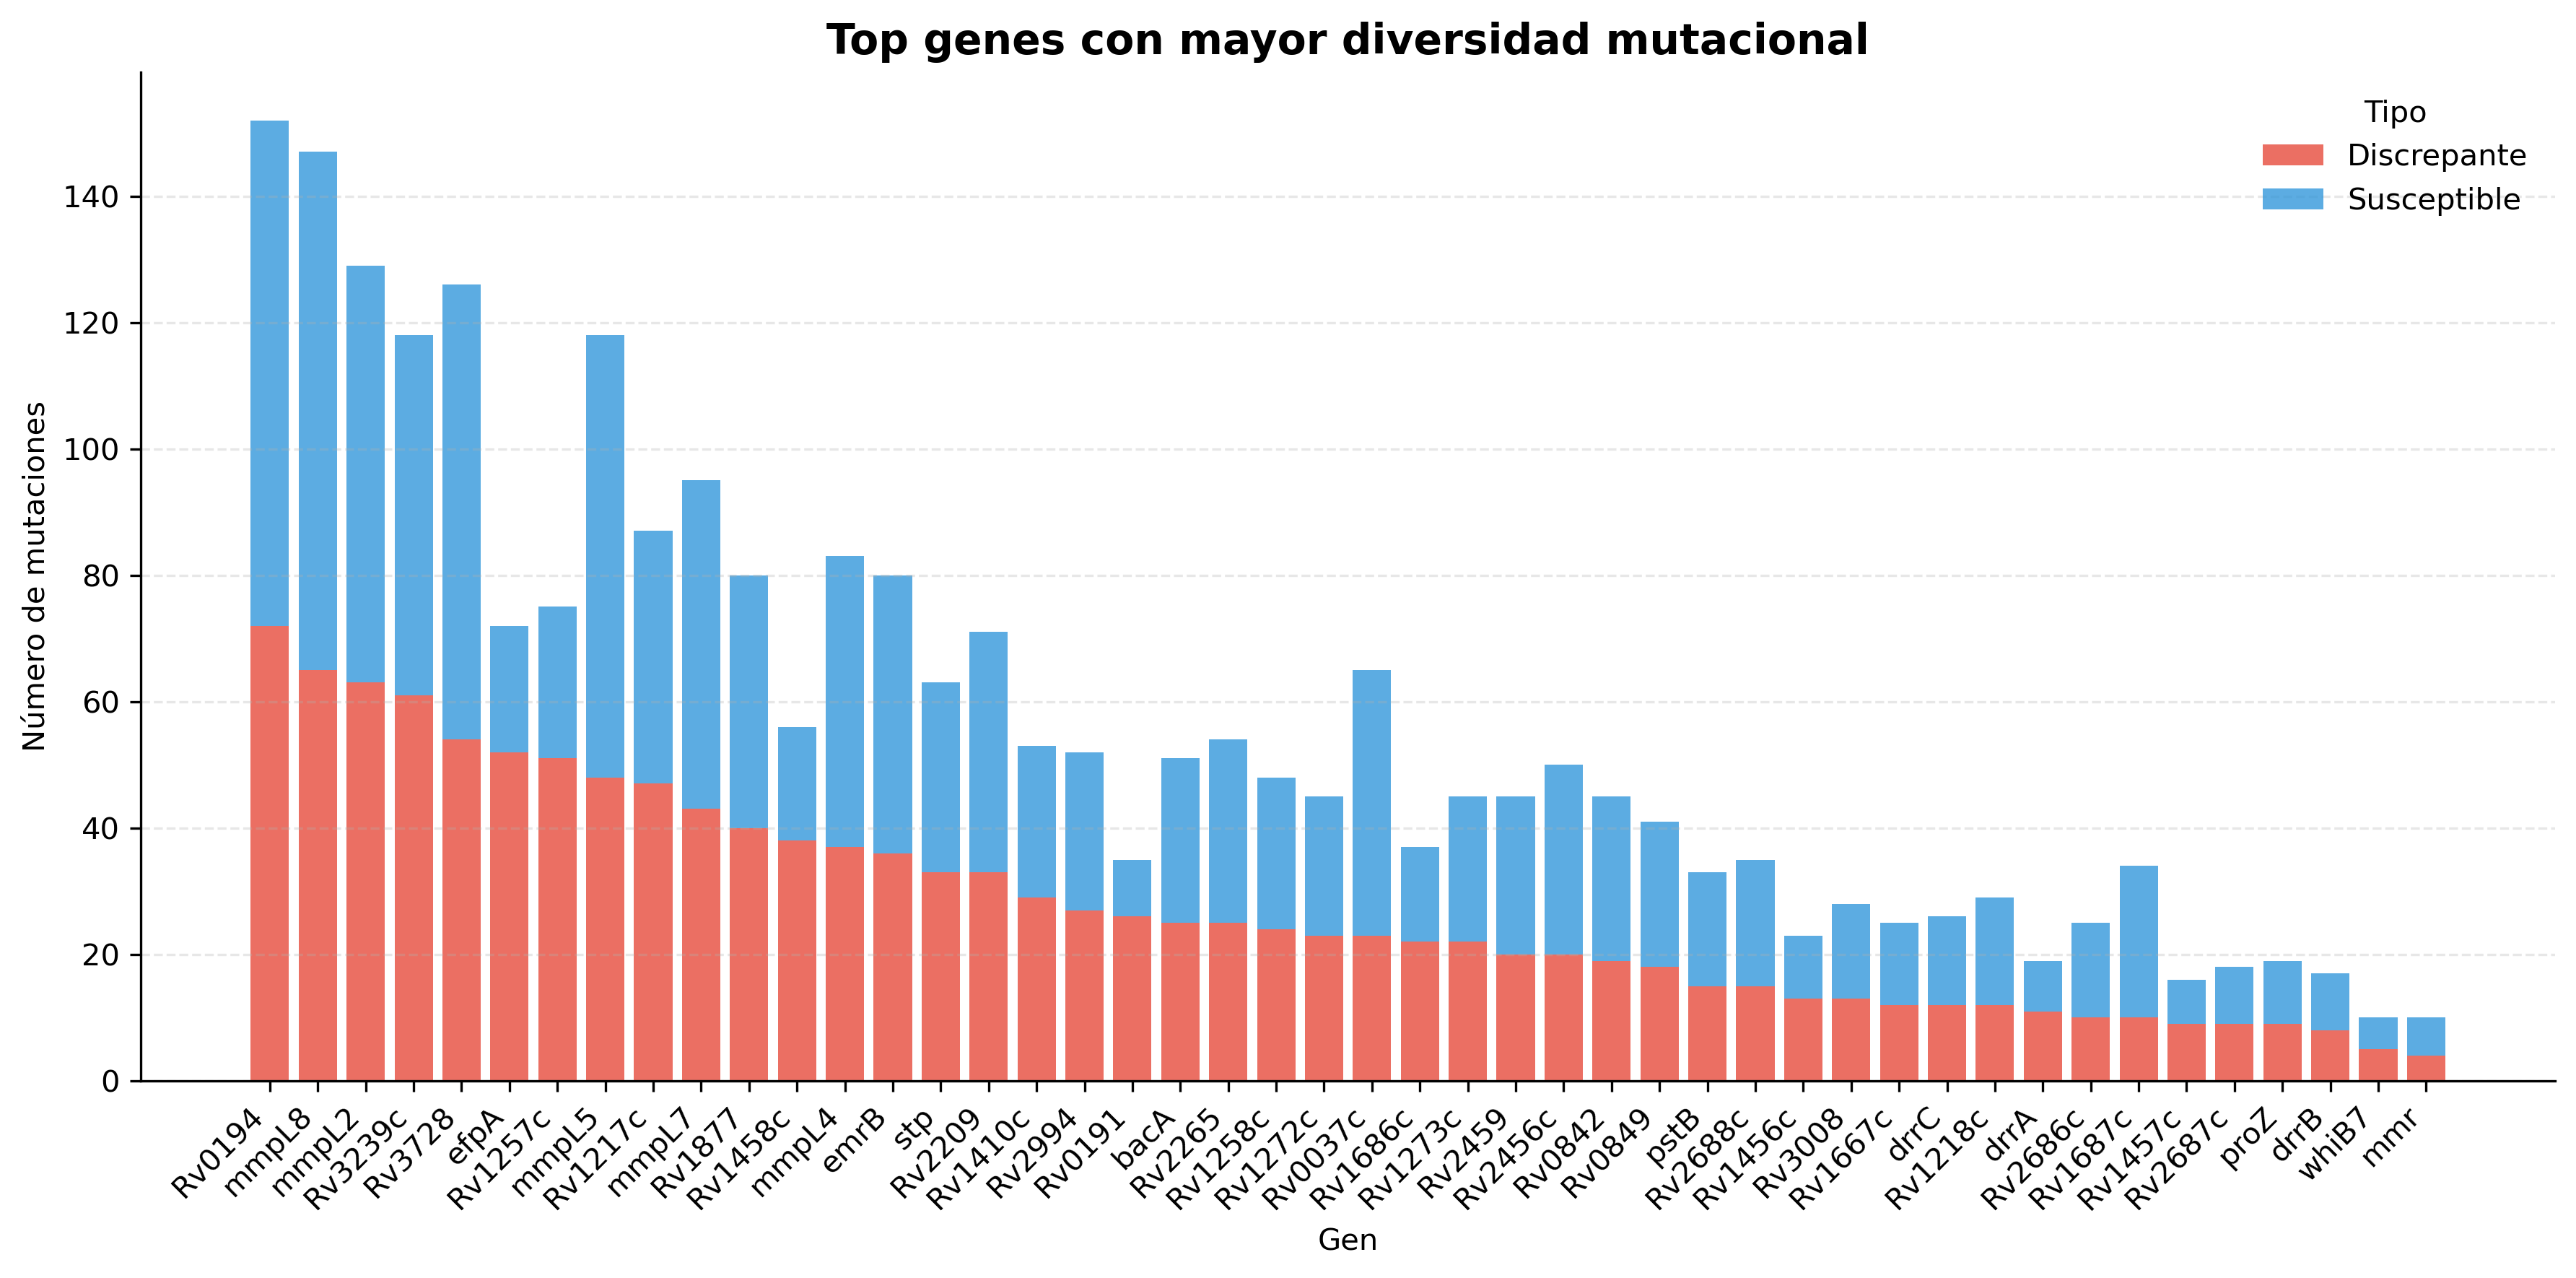

In [18]:
# Tabla de mutaciones por gen y fuente
top = df.groupby(["Tipo", "Gen"])["Mut"].nunique().unstack(level=0).sort_values(by=["Discrepante", "Susceptible"], ascending=[False, True])


# Figura 

fig, ax = plt.subplots(figsize=(12,6), dpi=300)
fig.patch.set_alpha(0)      # fondo figura transparente
ax.set_facecolor("none")    # fondo del área del plot transparente

ax.bar(top.index, top["Discrepante"], label="Discrepante", color="#e74c3c", alpha=0.8)
ax.bar(top.index, top["Susceptible"], label="Susceptible", color="#3498db", alpha=0.8, bottom=top["Discrepante"])

# Títulos más claros
ax.set_title("Top genes con mayor diversidad mutacional", fontsize=14, weight="bold")
ax.set_xlabel("Gen")
ax.set_ylabel("Número de mutaciones")

# Rotación y alineación
ax.tick_params(axis='x', rotation=45)
for label in ax.get_xticklabels():
    label.set_ha("right")

# Grid suave
ax.grid(axis='y', linestyle='--', alpha=0.3)

# Quitar bordes innecesarios (pro look)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.legend(title="Tipo", frameon=False)

plt.tight_layout()
plt.show()